In [45]:
from openpmd_api import Series, Access
import matplotlib.pyplot as plt
import numpy as np

In [46]:
series = Series("diags/diag/openpmd_%T.h5", Access.read_only)
its = sorted(series.iterations)
it = series.iterations[its[1]]      # iteration 10

B = it.meshes["B"]
Bx = B["x"].load_chunk()
By = B["y"].load_chunk()
Bz = B["z"].load_chunk()
series.flush()
#B2 = Bx**2 + By**2 + Bz**2

shape  = B["x"].shape            # cells per axis, e.g. [Nz, Nr] in RZ
dx     = B.grid_spacing          # cell size along each axis
x0     = B.grid_global_offset    # lower corner of the grid
axes   = B.axis_labels           # e.g. ('z', 'r') or ('x','y','z')
unit   = B.grid_unit_SI          # multiply spacing/offset by this for meters
geom   = B.geometry              # cartesian / thetaMode / etc.

# physical extents (in SI meters)
lo = [o * unit for o in x0]
hi = [(o + n * d) * unit for o, n, d in zip(x0, shape, dx)]

coords = [x0[i]*unit + (np.arange(shape[i]) + B["x"].position[i]) * dx[i] * unit for i in range(len(shape))][0]

In [47]:
print(coords.shape)
print(Bx.shape)

(64,)
(64, 64)


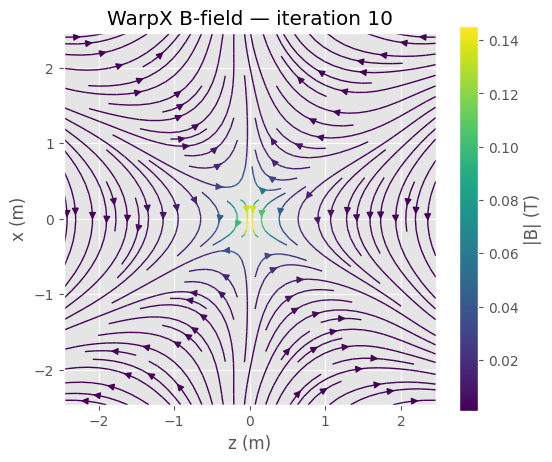

In [48]:
mag = np.hypot(Bx, Bz)

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords, coords, Bz, Bx,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("z (m)")
ax.set_ylabel("x (m)")
ax.set_title(f"WarpX B-field — iteration {its[1]}")
ax.set_aspect("equal")
plt.show()

## Compare the thing to magpylib

In [49]:
import magpylib as mp
from magpylib.current import Circle

bounds = 2.5 # m
ring_pos = (0,0,0)
ring_dia = 0.5 # m
ring_current = 1e5 # A

# make a circle coil aligned in the y-z plane
C = Circle(position=ring_pos, diameter=ring_dia, current=ring_current).rotate_from_angax(90, [0, 1, 0])

coords = np.linspace(-bounds, bounds, 100)

# get B-field from the grid
_grid = np.meshgrid(coords, np.zeros(100), coords, indexing='ij') # y-axis is always 0
grid = np.moveaxis(_grid, 0, -1)

B = C.getB(grid)
Bx, By, Bz = np.moveaxis(B, -1, 0)

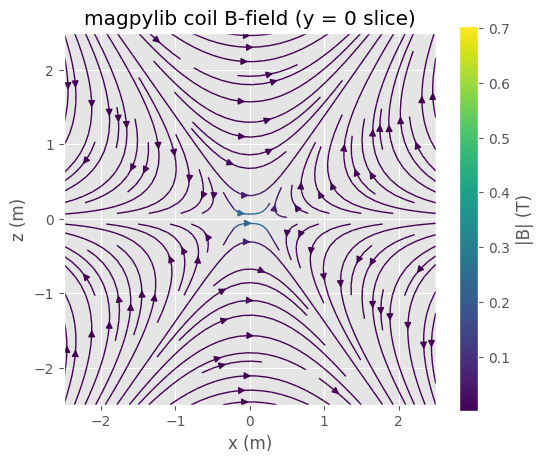

In [50]:
Bx_slice = Bx[:, 0, :]
Bz_slice = Bz[:, 0, :]
mag = np.hypot(Bx_slice, Bz_slice)

fig, ax = plt.subplots(figsize=(6, 5))
strm = ax.streamplot(
    coords, coords, Bx_slice, Bz_slice,
    color=mag, cmap="viridis", density=1.2, linewidth=1,
)
cb = fig.colorbar(strm.lines, ax=ax)
cb.set_label("|B| (T)")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("magpylib coil B-field (y = 0 slice)")
ax.set_aspect("equal")
plt.show()